### Load initial data

In [82]:
suppressPackageStartupMessages({
  library(ARTool)
  library(dplyr)
  library(readr)
})

# Load data
df <- read_csv("/media/jorvhar/Data8T/MRIData/PreProc/fMRI_art_data.csv", show_col_types = FALSE)

# ARTool will throw an error if 'pp' (Subject ID) is a number/double.
df <- df %>%
  mutate(
    pp = as.factor(pp),
    roi = as.factor(roi),
    layer = factor(layer, levels = c("Layer 1", "Layer 2", "Layer 3"), ordered = TRUE),
    Model = as.factor(Model)
  )

# all sets 'base', 'adaptation', 'prediction', 
# 'base_u_adaptation', 'base_u_prediction', 'adaptation_u_prediction','base_u_adaptation_u_prediction', 
# 'base*', 'adaptation*', 'prediction*',
# 'base_n_adaptation*', 'base_n_prediction*', 'adaptation_n_prediction*',
# 'base_n_adaptation_n_prediction', 'base_n_adaptation',
# 'base_n_prediction', 'adaptation_n_prediction',

# Use the exact names from your Python 'Model' column
target_models <- c("base*", "adaptation*", "prediction*", "base_n_adaptation*", "base_n_prediction*", "adaptation_n_prediction*")
analysis_df <- df %>% filter(Model %in% target_models)

### Do Pairwise ART-ANOVA over all ROIs as initial test

In [64]:
# Create a list of the pairs we want to compare
# Format: list(c(ModelA, ModelB), c(ModelA, ModelC), ...)
model_pairs <- list(
  c("prediction*", "adaptation*"),
  c("prediction*", "base*"),
  c("base*", "adaptation*")
)

# model_pairs <- list(
#   c("base_n_prediction*", "base_n_adaptation*"),
#   c("base_n_prediction*", "adaptation_n_prediction*"),
#   c("base_n_adaptation*", "adaptation_n_prediction*")
# )

# Loop through each pair of models within this ROI
for (pair in model_pairs) {
    cat("\n--- Comparison:", pair[1], "vs.", pair[2], "---\n")

    # Subset for the first pair
    pair_df <- analysis_df %>% 
      filter(Model %in% pair) %>%
      mutate(Model = factor(Model)) # Drop the unused 'base' level

    ## run paired-ART Anova
    m_pair <- art(Response ~ layer * Model + (1|pp), data = pair_df)
    print(anova(m_pair))
    }


--- Comparison: prediction* vs. adaptation* ---
Analysis of Variance of Aligned Rank Transformed Data

Table Type: Analysis of Deviance Table (Type III Wald F tests with Kenward-Roger df) 
Model: Mixed Effects (lmer)
Response: art(Response)

                   F Df Df.res     Pr(>F)    
1 layer       28.934  2    285 3.6301e-12 ***
2 Model       13.235  1    285 0.00032615 ***
3 layer:Model 17.159  2    285 9.1925e-08 ***
---
Signif. codes:   0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1 

--- Comparison: prediction* vs. base* ---
Analysis of Variance of Aligned Rank Transformed Data

Table Type: Analysis of Deviance Table (Type III Wald F tests with Kenward-Roger df) 
Model: Mixed Effects (lmer)
Response: art(Response)

                    F Df Df.res     Pr(>F)    
1 layer       34.2771  2    285 4.5752e-14 ***
2 Model       14.1388  1    285 0.00020604 ***
3 layer:Model  6.1365  2    285 0.00245883  **
---
Signif. codes:   0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1 

--- Compa

### Then repeat but now per ROI

In [105]:
# Define the ROIs you want to loop through
rois <- unique(analysis_df$roi)
rois <- rois[rois != "PP_combined"]
rois <- rois[rois != "HG_combined"]

# Create a list of the pairs we want to compare
# Format: list(c(ModelA, ModelB), c(ModelA, ModelC), ...)
model_pairs <- list(
  c("prediction*", "adaptation*"),
  c("prediction*", "base*"),
  c("base*", "adaptation*")
)

model_pairs <- list(
  c("base_n_prediction*", "base_n_adaptation*"),
  c("base_n_prediction*", "adaptation_n_prediction*"),
  c("base_n_adaptation*", "adaptation_n_prediction*")
)

# Initialize storage
results_list <- list()

# Loop through each ROI
for (current_roi in rois) {
  cat("\n================================================================\n")
  cat("ANALYSIS FOR ROI:", as.character(current_roi), "\n")
  cat("================================================================\n")
  
  # Filter data for this specific ROI
  roi_df <- analysis_df %>% filter(roi == current_roi)
  
  # Loop through each pair of models within this ROI
  for (pair in model_pairs) {
    cat("\n--- Comparison:", pair[1], "vs.", pair[2], "---\n")
    
    # Subset for the specific pair and drop unused factor levels
    pair_df <- roi_df %>% 
      filter(Model %in% pair) %>%
      mutate(Model = factor(Model))
    
    # Run the ART ANOVA
    # We catch errors in case an ROI has missing data for a specific model
    tryCatch({
      m_pair <- art(Response ~ layer * Model + (1|pp), data = pair_df)

      # Store results in the list
      res <- as.data.frame(anova(m_pair))
      results_list[[length(results_list) + 1]] <- cbind(res, roi = current_roi, pair1 = pair[1], pair2 = pair[2], term = rownames(res))
    
      print(anova(m_pair))
    }, error = function(e) {
      cat("Error in this comparison: ", e$message, "\n")
    })
  }
}


ANALYSIS FOR ROI: PT_combined 

--- Comparison: base_n_prediction* vs. base_n_adaptation* ---
Analysis of Variance of Aligned Rank Transformed Data

Table Type: Analysis of Deviance Table (Type III Wald F tests with Kenward-Roger df) 
Model: Mixed Effects (lmer)
Response: art(Response)

                     F Df Df.res     Pr(>F)    
1 layer         6.0719  2     45  0.0046288  **
2 Model       112.2895  1     45 8.2037e-14 ***
3 layer:Model   2.3493  2     45  0.1070377    
---
Signif. codes:   0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1 

--- Comparison: base_n_prediction* vs. adaptation_n_prediction* ---
Analysis of Variance of Aligned Rank Transformed Data

Table Type: Analysis of Deviance Table (Type III Wald F tests with Kenward-Roger df) 
Model: Mixed Effects (lmer)
Response: art(Response)

                    F Df Df.res     Pr(>F)    
1 layer        6.2353  2     45  0.0040715  **
2 Model       60.8484  1     45 6.7364e-10 ***
3 layer:Model  7.4379  2     45  0.0016185  **

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')



Analysis of Variance of Aligned Rank Transformed Data

Table Type: Analysis of Deviance Table (Type III Wald F tests with Kenward-Roger df) 
Model: Mixed Effects (lmer)
Response: art(Response)

                     F Df Df.res     Pr(>F)    
1 layer        0.31495  2     45   0.731421    
2 Model       41.21004  1     45 7.4275e-08 ***
3 layer:Model  2.57191  2     45   0.087577   .
---
Signif. codes:   0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1 

ANALYSIS FOR ROI: aSTG_combined 

--- Comparison: base_n_prediction* vs. base_n_adaptation* ---
Analysis of Variance of Aligned Rank Transformed Data

Table Type: Analysis of Deviance Table (Type III Wald F tests with Kenward-Roger df) 
Model: Mixed Effects (lmer)
Response: art(Response)

                     F Df Df.res   Pr(>F)    
1 layer         6.2672  2     45 0.003971  **
2 Model       233.6590  1     45  < 2e-16 ***
3 layer:Model   2.8417  2     45 0.068833   .
---
Signif. codes:   0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1 



boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')



Analysis of Variance of Aligned Rank Transformed Data

Table Type: Analysis of Deviance Table (Type III Wald F tests with Kenward-Roger df) 
Model: Mixed Effects (lmer)
Response: art(Response)

                      F Df Df.res   Pr(>F)    
1 layer         0.14159  2     45 0.868360    
2 Model       166.87726  1     45  < 2e-16 ***
3 layer:Model   4.02432  2     45 0.024667   *
---
Signif. codes:   0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1 

ANALYSIS FOR ROI: pSTG_combined 

--- Comparison: base_n_prediction* vs. base_n_adaptation* ---
Analysis of Variance of Aligned Rank Transformed Data

Table Type: Analysis of Deviance Table (Type III Wald F tests with Kenward-Roger df) 
Model: Mixed Effects (lmer)
Response: art(Response)

                     F Df Df.res     Pr(>F)    
1 layer        16.1817  2     45 5.0727e-06 ***
2 Model       270.6657  1     45 < 2.22e-16 ***
3 layer:Model   5.7619  2     45  0.0059169  **
---
Signif. codes:   0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')



Analysis of Variance of Aligned Rank Transformed Data

Table Type: Analysis of Deviance Table (Type III Wald F tests with Kenward-Roger df) 
Model: Mixed Effects (lmer)
Response: art(Response)

                      F Df Df.res     Pr(>F)    
1 layer         0.15124  2     45   0.860075    
2 Model       146.49086  1     45 9.4895e-16 ***
3 layer:Model   3.04038  2     45   0.057742   .
---
Signif. codes:   0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1 


In [102]:
## FDR

# Combine and apply FDR
all_results <- do.call(rbind, results_list) %>%
  mutate(p_fdr = p.adjust(`Pr(>F)`, method = "fdr"))

# Display the results table with FDR
all_results %>%
  select(roi, pair1, pair2, term, p_fdr, `Pr(>F)`) %>%
  print()

                       roi              pair1                    pair2
layer          PT_combined base_n_prediction*       base_n_adaptation*
Model          PT_combined base_n_prediction*       base_n_adaptation*
layer:Model    PT_combined base_n_prediction*       base_n_adaptation*
layer1         PT_combined base_n_prediction* adaptation_n_prediction*
Model1         PT_combined base_n_prediction* adaptation_n_prediction*
layer:Model1   PT_combined base_n_prediction* adaptation_n_prediction*
layer2         PT_combined base_n_adaptation* adaptation_n_prediction*
Model2         PT_combined base_n_adaptation* adaptation_n_prediction*
layer:Model2   PT_combined base_n_adaptation* adaptation_n_prediction*
layer3       aSTG_combined base_n_prediction*       base_n_adaptation*
Model3       aSTG_combined base_n_prediction*       base_n_adaptation*
layer:Model3 aSTG_combined base_n_prediction*       base_n_adaptation*
layer4       aSTG_combined base_n_prediction* adaptation_n_prediction*
Model4

## Same but now just 3x3 anova

In [103]:
# Define the ROIs you want to loop through
rois <- unique(analysis_df$roi)

# Create a list of the pairs we want to compare
# Format: list(c(ModelA, ModelB), c(ModelA, ModelC), ...)
model_pairs <- list(
  c("prediction*", "adaptation*", "base*"),
  c("base_n_prediction*", "base_n_adaptation*", "adaptation_n_prediction*")
)

model_pairs <- list(
  c("base_n_prediction*", "base_n_adaptation*", "adaptation_n_prediction*")
)

# model_pairs <- list(
#   c("base_n_prediction*", "base_n_adaptation*"),
#   c("base_n_prediction*", "adaptation_n_prediction*"),
#   c("base_n_adaptation*", "adaptation_n_prediction*")
# )

# Initialize storage
results_list <- list()

# Loop through each ROI
for (current_roi in rois) {
  cat("\n================================================================\n")
  cat("ANALYSIS FOR ROI:", as.character(current_roi), "\n")
  cat("================================================================\n")
  
  # Filter data for this specific ROI
  roi_df <- analysis_df %>% filter(roi == current_roi)
  
  # Loop through each pair of models within this ROI
  for (pair in model_pairs) {
    cat("\n--- Comparison:", pair, "---\n")
    
    # Subset for the specific pair and drop unused factor levels
    pair_df <- roi_df %>% 
      filter(Model %in% pair) %>%
      mutate(Model = factor(Model))
    
    # Run the ART ANOVA
    # We catch errors in case an ROI has missing data for a specific model
    tryCatch({
      m_pair <- art(Response ~ layer * Model + (1|pp), data = pair_df)

      # Store results in the list
      res <- as.data.frame(anova(m_pair))
      results_list[[length(results_list) + 1]] <- cbind(res, roi = current_roi, term = rownames(res))
        
      print(anova(m_pair))
    }, error = function(e) {
      cat("Error in this comparison: ", e$message, "\n")
    })
  }
}


ANALYSIS FOR ROI: HG_combined 

--- Comparison: base_n_prediction* base_n_adaptation* adaptation_n_prediction* ---
Analysis of Variance of Aligned Rank Transformed Data

Table Type: Analysis of Deviance Table (Type III Wald F tests with Kenward-Roger df) 
Model: Mixed Effects (lmer)
Response: art(Response)

                    F Df Df.res     Pr(>F)    
1 layer        2.3066  2     72    0.10692    
2 Model       31.2614  2     72 1.6878e-10 ***
3 layer:Model  2.3589  4     72    0.06141   .
---
Signif. codes:   0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1 

ANALYSIS FOR ROI: PP_combined 

--- Comparison: base_n_prediction* base_n_adaptation* adaptation_n_prediction* ---
Analysis of Variance of Aligned Rank Transformed Data

Table Type: Analysis of Deviance Table (Type III Wald F tests with Kenward-Roger df) 
Model: Mixed Effects (lmer)
Response: art(Response)

                     F Df Df.res  Pr(>F)    
1 layer        0.66287  2     72 0.51849    
2 Model       86.87610  2     72 

In [104]:
## FDR

# Combine and apply FDR
all_results <- do.call(rbind, results_list) %>%
  mutate(p_fdr = p.adjust(`Pr(>F)`, method = "fdr"))

# Display the results table with FDR
all_results %>%
  select(roi, term, `Pr(>F)`, p_fdr) %>%
  print()

                       roi        term       Pr(>F)        p_fdr
layer          HG_combined       layer 1.069189e-01 1.210821e-01
Model          HG_combined       Model 1.687753e-10 5.063259e-10
layer:Model    HG_combined layer:Model 6.140984e-02 7.676230e-02
layer1         PP_combined       layer 5.184878e-01 5.184878e-01
Model1         PP_combined       Model 6.398269e-20 3.199135e-19
layer:Model1   PP_combined layer:Model 1.130099e-01 1.210821e-01
layer2         PT_combined       layer 4.259261e-03 7.098769e-03
Model2         PT_combined       Model 1.550262e-17 5.813482e-17
layer:Model2   PT_combined layer:Model 7.862680e-03 1.179402e-02
layer3       aSTG_combined       layer 2.313649e-02 3.154976e-02
Model3       aSTG_combined       Model 1.844758e-23 1.383569e-22
layer:Model3 aSTG_combined layer:Model 8.755710e-04 1.641696e-03
layer4       pSTG_combined       layer 3.347048e-04 7.172245e-04
Model4       pSTG_combined       Model 6.241947e-29 9.362921e-28
layer:Model4 pSTG_combine

## Then for draining veins

In [57]:
# all sets 'base', 'adaptation', 'prediction', 
# 'base_u_adaptation', 'base_u_prediction', 'adaptation_u_prediction','base_u_adaptation_u_prediction', 
# 'base*', 'adaptation*', 'prediction*',
# 'base_n_adaptation*', 'base_n_prediction*', 'adaptation_n_prediction*',
# 'base_n_adaptation_n_prediction', 'base_n_adaptation',
# 'base_n_prediction', 'adaptation_n_prediction',

# Use the exact names from your Python 'Model' column
target_models <- c("base_u_adaptation_u_prediction", "base_n_adaptation_n_prediction")
analysis_df <- df %>% filter(Model %in% target_models)

# Define the ROIs you want to loop through
rois <- unique(analysis_df$roi)

# Create a list of the pairs we want to compare
# Format: list(c(ModelA, ModelB), c(ModelA, ModelC), ...)
model_pairs <- list(
  c("base_u_adaptation_u_prediction", "base_n_adaptation_n_prediction")
)

# model_pairs <- list(
#   c("base_n_prediction*", "base_n_adaptation*"),
#   c("base_n_prediction*", "adaptation_n_prediction*"),
#   c("base_n_adaptation*", "adaptation_n_prediction*")
# )

# Loop through each ROI
for (current_roi in rois) {
  cat("\n================================================================\n")
  cat("ANALYSIS FOR ROI:", as.character(current_roi), "\n")
  cat("================================================================\n")
  
  # Filter data for this specific ROI
  roi_df <- analysis_df %>% filter(roi == current_roi)
  
  # Loop through each pair of models within this ROI
  for (pair in model_pairs) {
    cat("\n--- Comparison:", pair[1], "vs.", pair[2], "---\n")
    
    # Subset for the specific pair and drop unused factor levels
    pair_df <- roi_df %>% 
      filter(Model %in% pair) %>%
      mutate(Model = factor(Model))
    
    # Run the ART ANOVA
    # We catch errors in case an ROI has missing data for a specific model
    tryCatch({
      m_pair <- art(Response ~ layer * Model + (1|pp), data = pair_df)
      print(anova(m_pair))
    }, error = function(e) {
      cat("Error in this comparison: ", e$message, "\n")
    })
  }
}


ANALYSIS FOR ROI: HG_combined 

--- Comparison: base_u_adaptation_u_prediction vs. base_n_adaptation_n_prediction ---
Analysis of Variance of Aligned Rank Transformed Data

Table Type: Analysis of Deviance Table (Type III Wald F tests with Kenward-Roger df) 
Model: Mixed Effects (lmer)
Response: art(Response)

                      F Df Df.res  Pr(>F)    
1 layer       109.34645  2     45 < 2e-16 ***
2 Model       184.39642  1     45 < 2e-16 ***
3 layer:Model   0.62652  2     45 0.53904    
---
Signif. codes:   0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1 

ANALYSIS FOR ROI: PP_combined 

--- Comparison: base_u_adaptation_u_prediction vs. base_n_adaptation_n_prediction ---
Analysis of Variance of Aligned Rank Transformed Data

Table Type: Analysis of Deviance Table (Type III Wald F tests with Kenward-Roger df) 
Model: Mixed Effects (lmer)
Response: art(Response)

                      F Df Df.res     Pr(>F)    
1 layer        28.77387  2     45 8.9422e-09 ***
2 Model       286.55661

In [59]:
library(ARTool)
library(dplyr)
library(purrr)

# 1. Initialize a list to store results
results_list <- list()

# 2. Your existing loop with a slight modification to save p-values
for (current_roi in rois) {
  roi_df <- analysis_df %>% filter(roi == current_roi)
  
  for (pair in model_pairs) {
    pair_label <- paste(pair[1], "vs", pair[2])
    
    pair_df <- roi_df %>% 
      filter(Model %in% pair) %>%
      mutate(Model = factor(Model))
    
    tryCatch({
      m_pair <- art(Response ~ layer * Model + (1|pp), data = pair_df)
      anova_res <- as.data.frame(anova(m_pair))
      
      # Add metadata to the results table
      anova_res$ROI <- current_roi
      anova_res$Comparison <- pair_label
      anova_res$Term <- rownames(anova_res) # layer, Model, layer:Model
      
      results_list[[length(results_list) + 1]] <- anova_res
    }, error = function(e) {
      message("Error in ROI ", current_roi, ": ", e$message)
    })
  }
}

# 3. Combine all results into one data frame
final_results <- bind_rows(results_list)

# 4. Apply FDR Correction
# We apply this to the 'Pr(>F)' column across all tests performed
final_results <- final_results %>%
  mutate(p_fdr = p.adjust(`Pr(>F)`, method = "fdr")) %>%
  select(ROI, Comparison, Term, `F`, `Pr(>F)`, p_fdr, everything())

# 5. View the significant results
print(final_results)

                           ROI
layer...1          HG_combined
Model...2          HG_combined
layer:Model...3    HG_combined
layer...4          PP_combined
Model...5          PP_combined
layer:Model...6    PP_combined
layer...7          PT_combined
Model...8          PT_combined
layer:Model...9    PT_combined
layer...10       aSTG_combined
Model...11       aSTG_combined
layer:Model...12 aSTG_combined
layer...13       pSTG_combined
Model...14       pSTG_combined
layer:Model...15 pSTG_combined
                                                                       Comparison
layer...1        base_u_adaptation_u_prediction vs base_n_adaptation_n_prediction
Model...2        base_u_adaptation_u_prediction vs base_n_adaptation_n_prediction
layer:Model...3  base_u_adaptation_u_prediction vs base_n_adaptation_n_prediction
layer...4        base_u_adaptation_u_prediction vs base_n_adaptation_n_prediction
Model...5        base_u_adaptation_u_prediction vs base_n_adaptation_n_prediction
layer:Model.

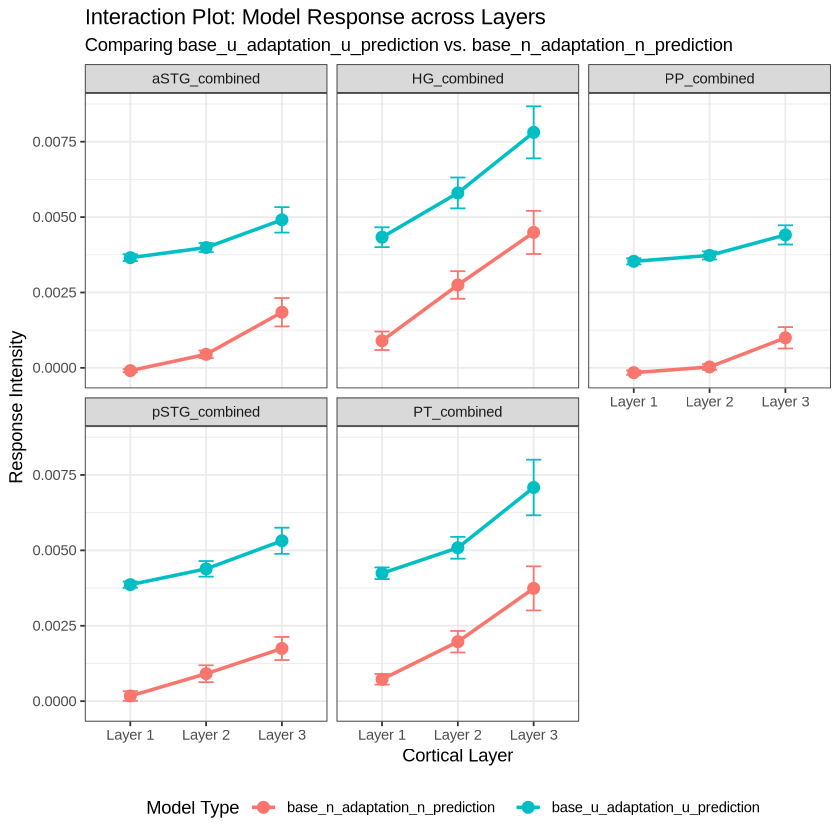

In [58]:
library(ggplot2)

# Assuming analysis_df has columns: layer, Response, Model, roi
# This will show the interaction between Model and Layer for each ROI
ggplot(analysis_df, aes(x = layer, y = Response, color = Model, group = Model)) +
  # Calculate means and draw lines/points
  stat_summary(fun = mean, geom = "point", size = 3) +
  stat_summary(fun = mean, geom = "line", linewidth = 1) +
  # Add standard error bars
  stat_summary(fun.data = mean_se, geom = "errorbar", width = 0.2) +
  # Separate plot for each ROI
  facet_wrap(~roi) +
  # Aesthetics
  theme_bw() +
  labs(title = "Interaction Plot: Model Response across Layers",
       subtitle = "Comparing base_u_adaptation_u_prediction vs. base_n_adaptation_n_prediction",
       x = "Cortical Layer",
       y = "Response Intensity",
       color = "Model Type") +
  theme(legend.position = "bottom")